# **Assignment 9**

In [6]:
# core
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ml
from sklearn import datasets as ds
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import train_test_split as tts

#plotly or other graphing library

In [3]:
# Load datasets here once and assign to variables iris and boston

iris = ds.load_iris()

**Q1**

**Data set: Iris**

* Return the first 5 rows of the data including the feature names as column headings in a DataFrame and a
separate Python list containing target names

In [7]:
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

target_names = list(iris.target_names)

iris_df.head(), target_names

(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                5.1               3.5                1.4               0.2
 1                4.9               3.0                1.4               0.2
 2                4.7               3.2                1.3               0.2
 3                4.6               3.1                1.5               0.2
 4                5.0               3.6                1.4               0.2,
 [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')])

**Q2**

**Data set: Iris**

* Fit the Iris dataset into a kNN model with neighbors=5 and predict the category of observations passed in
argument new_observations. Return back the target names of each prediction (and not their encoded values,
 i.e. return setosa instead of 0).

In [ ]:
def predict_iris(new_observations):
    knn = KNN(n_neighbors=5)
    knn.fit(iris.data, iris.target)

    predictions = knn.predict(new_observations)

    return list(iris.target_names[predictions])

new_observations = [
    [5.2, 3.5, 1.6, 0.6],
    [5.9, 2.8, 4.9, 1.7],
    [6.4, 3.1, 5.1, 1.9]
]

predict_iris(new_observations)

[np.str_('setosa'), np.str_('virginica'), np.str_('virginica')]

**Q3**

**Data set: Iris**

* Split the Iris dataset into a train / test model with the split ratio between the two established by the function parameter split.

* Fit KNN with the training data with number of neighbors equal to the function parameter neighbors

* Generate and return back an accuracy score using the test data that was split out

In [53]:
def iris_knn_accuracy(split, neighbors):
    X_train, X_test, y_train, y_test = tts(
        iris.data,
        iris.target,
        test_size=split,
        random_state=21,
        stratify=iris.target
    )

    model = KNN(n_neighbors=neighbors)
    model.fit(X_train, y_train)

    return model.score(X_test, y_test)

print(iris_knn_accuracy(0.3, 6))
print(iris_knn_accuracy(0.3, 12))
print(iris_knn_accuracy(0.3, 18))

0.9555555555555556
0.9555555555555556
0.9555555555555556


**Q4**

**Data set: Iris**

* Generate an overfitting / underfitting curve of kNN each of the testing and training accuracy performance scores series for a range of neighbor (k) values from 1 to 30 and plot the curves (number of neighbors is x-axis, performance score is y-axis on the chart).

In [54]:
X_train, X_test, y_train, y_test = tts(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state = 21,
    stratify=iris.target
)

k_values = range(1, 31)

train_scores = {}
test_scores = {}

k_values = np.arange(1, 31)

for k in k_values:
    model = KNN(n_neighbors=k)
    model.fit(X_train, y_train)

    train_scores[k] = model.score(X_train, y_train)
    test_scores[k] = model.score(X_test, y_test)

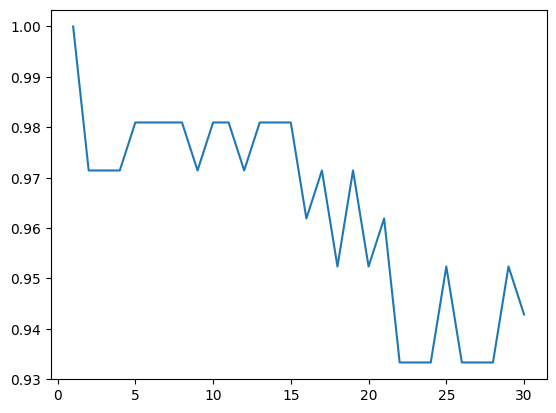

In [55]:
plt.plot(k_values, train_scores.values(), label="Training Accuracy")

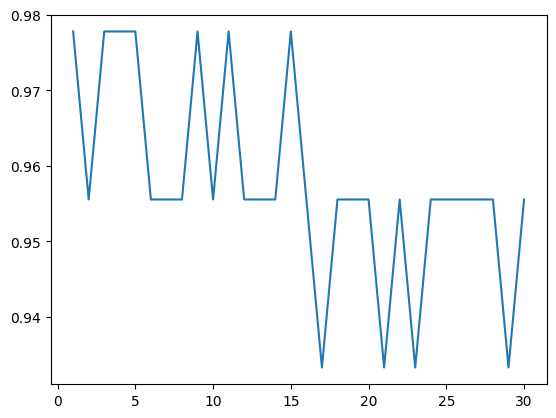

In [45]:
plt.plot(k_values, test_scores.values(), label="Testing Accuracy")

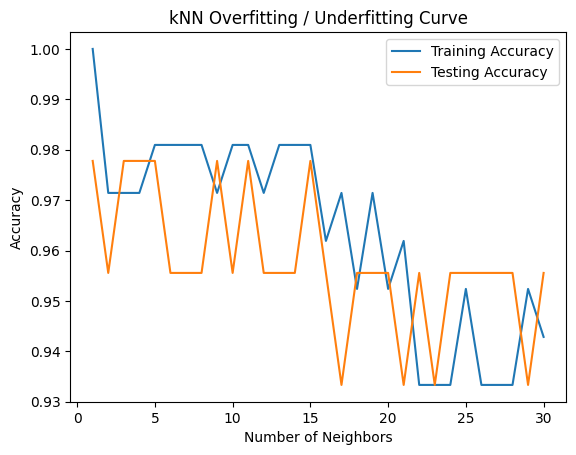

In [46]:
plt.plot(k_values, train_scores.values(), label="Training Accuracy")
plt.plot(k_values, test_scores.values(), label="Testing Accuracy")
plt.title("kNN Overfitting / Underfitting Curve")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()